# Saliency-Based Data Cleaning: Self-Supervised Saliency Auditing

## Concept
Traditional data cleaning focuses on label noise (mislabeled examples) or feature noise (outliers). **Saliency-Based Data Cleaning** leverages the *explanations* of a model to identify "suspicious" data points.

### The Core Hypothesis:
A model trained on clean data should focus on the *correct features* (the signal). If a data point is mislabeled or contains spurious correlations (shortcuts), the model's saliency map will often:
1.  **Shift to the background** (looking for the shortcut).
2.  **Become incoherent/diffuse** (the model is confused).
3.  **Focus on non-discriminative features.**

By auditing the *masks* (saliency maps) generated for the training set, we can flag data points where the model's "reasoning" is inconsistent with the expected domain knowledge.

## Proposed Workflow:
1.  **Initial Training:** Train a model on the (potentially noisy) dataset.
2.  **Saliency Generation:** Generate saliency maps (masks) for all training examples.
3.  **Audit/Filtering:** Use `saliencytools` (like `maskcompare`) or simple heuristics (mask sparsity, centroid location, alignment with a "template") to flag examples with anomalous saliency.
4.  **Cleaning:** Remove or relabel the flagged examples and retrain.

## In this notebook:
- We will simulate label noise in MNIST.
- We will visualize how saliency maps differ for correct vs. incorrect labels.
- We will implement a simple auditing heuristic.

In [4]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, Subset, Dataset
import matplotlib.pyplot as plt
import numpy as np
import os
import sys

# Add the project root to sys.path to import saliencytools
sys.path.append('../../')
from saliencytools.maskcompare import (
    normalize_mask_0_1,
    cosine_distance,
    euclidean_distance,
    emd
)

# Set seed for reproducibility
torch.manual_seed(42)
np.random.seed(42)

# Device configuration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# 1. Load MNIST Data
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

# Use a fresh download and local path
data_dir = './data'
os.makedirs(data_dir, exist_ok=True)

train_dataset = torchvision.datasets.MNIST(root=data_dir, train=True, download=True, transform=transform)

# 2. Simulate Label Noise (Inject 10% Noise)
noise_rate = 0.1
subset_size = 2000 # Smaller subset for faster execution
num_noisy = int(subset_size * noise_rate)

# We'll work on a subset from the start
subset_indices = np.random.choice(len(train_dataset), subset_size, replace=False)
subset_images = train_dataset.data[subset_indices]
subset_targets = train_dataset.targets[subset_indices].clone()
true_targets = subset_targets.clone()

# Inject noise into subset_targets
noisy_indices_in_subset = np.random.choice(subset_size, num_noisy, replace=False)
for idx in noisy_indices_in_subset:
    original_label = subset_targets[idx].item()
    new_label = np.random.randint(0, 10)
    while new_label == original_label:
        new_label = np.random.randint(0, 10)
    subset_targets[idx] = new_label

# Create a Custom Dataset for our subset
class CustomMNIST(Dataset):
    def __init__(self, images, targets, transform=None):
        self.images = images
        self.targets = targets
        self.transform = transform
    def __len__(self):
        return len(self.images)
    def __getitem__(self, idx):
        img = self.images[idx].numpy()
        # Convert to PIL Image for transform
        from PIL import Image
        img = Image.fromarray(img, mode='L')
        if self.transform:
            img = self.transform(img)
        return img, self.targets[idx], idx

train_subset = CustomMNIST(subset_images, subset_targets, transform=transform)
train_loader = DataLoader(train_subset, batch_size=64, shuffle=True)

# 3. Define a Simple CNN
class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()
        self.conv1 = nn.Conv2d(1, 16, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)
        self.fc1 = nn.Linear(32 * 7 * 7, 128)
        self.fc2 = nn.Linear(128, 10)
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.pool(self.relu(self.conv1(x)))
        x = self.pool(self.relu(self.conv2(x)))
        x = x.view(-1, 32 * 7 * 7)
        x = self.relu(self.fc1(x))
        x = self.fc2(x)
        return x

model = SimpleCNN().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# 4. Train the Model
num_epochs = 5
print(f"Training on {subset_size} samples with {int(noise_rate * 100)}% noise...")
for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    for images, labels, _ in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
    print(f"Epoch {epoch+1}/{num_epochs}, Loss: {running_loss/len(train_loader):.4f}")

print("Training finished.")

Training on 2000 samples with 10% noise...
Epoch 1/5, Loss: 1.6122
Epoch 2/5, Loss: 0.9495
Epoch 3/5, Loss: 0.7970
Epoch 4/5, Loss: 0.7384
Epoch 5/5, Loss: 0.6752
Training finished.


Generating saliency maps for auditing...
Mean distance for clean samples: 0.2258
Mean distance for noisy samples: 0.2946


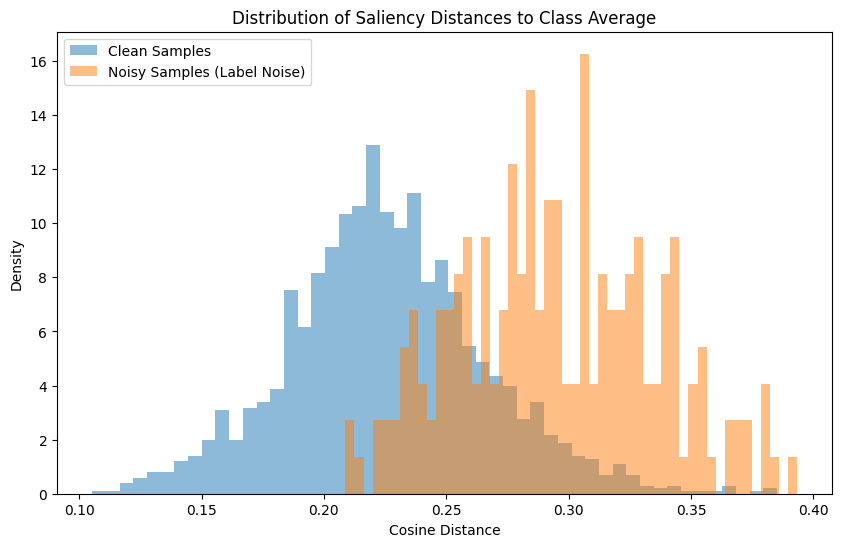

In [5]:
# 5. Generate Saliency Maps and Audit

def get_gradients(model, image, label):
    model.eval()
    image = image.unsqueeze(0).to(device)
    image.requires_grad = True
    output = model(image)
    loss = criterion(output, torch.tensor([label]).to(device))
    loss.backward()
    grad = image.grad.detach().cpu().numpy()[0, 0]
    return normalize_mask_0_1(np.abs(grad))

all_masks = []
all_labels = []
all_indices = []

print("Generating saliency maps for auditing...")
for i in range(len(train_subset)):
    img, label, idx = train_subset[i]
    mask = get_gradients(model, img, label)
    all_masks.append(mask)
    all_labels.append(label.item())
    all_indices.append(idx)

all_masks = np.array(all_masks)
all_labels = np.array(all_labels)

# 6. Compute Average Mask per Class
class_avg_masks = {}
for label in range(10):
    indices = np.where(all_labels == label)[0]
    if len(indices) > 0:
        class_avg_masks[label] = np.mean(all_masks[indices], axis=0)

# 7. Audit: Compute distance to class average
distances = []
for i in range(len(all_masks)):
    label = all_labels[i]
    dist = cosine_distance(all_masks[i], class_avg_masks[label])
    distances.append(dist)

distances = np.array(distances)

# 8. Evaluation: Are noisy samples more "distant"?
# true_targets vs subset_targets
is_noisy = (true_targets != subset_targets).numpy()

noisy_distances = distances[is_noisy]
clean_distances = distances[~is_noisy]

print(f"Mean distance for clean samples: {np.mean(clean_distances):.4f}")
print(f"Mean distance for noisy samples: {np.mean(noisy_distances):.4f}")

# Visualize distributions
plt.figure(figsize=(10, 6))
plt.hist(clean_distances, bins=50, alpha=0.5, label='Clean Samples', density=True)
plt.hist(noisy_distances, bins=50, alpha=0.5, label='Noisy Samples (Label Noise)', density=True)
plt.title("Distribution of Saliency Distances to Class Average")
plt.xlabel("Cosine Distance")
plt.ylabel("Density")
plt.legend()
plt.show()

Visualizing TOP Suspicious Samples (Highest Saliency Distance)...


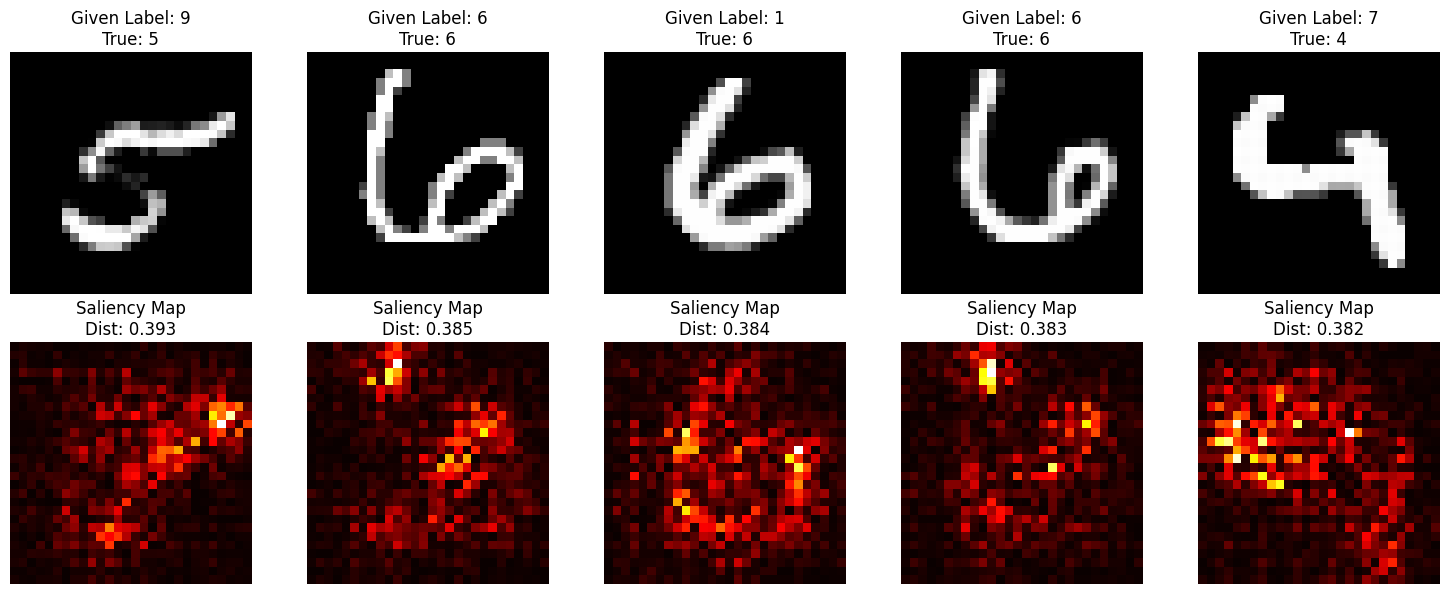

Visualizing TOP Typical Samples (Lowest Saliency Distance)...


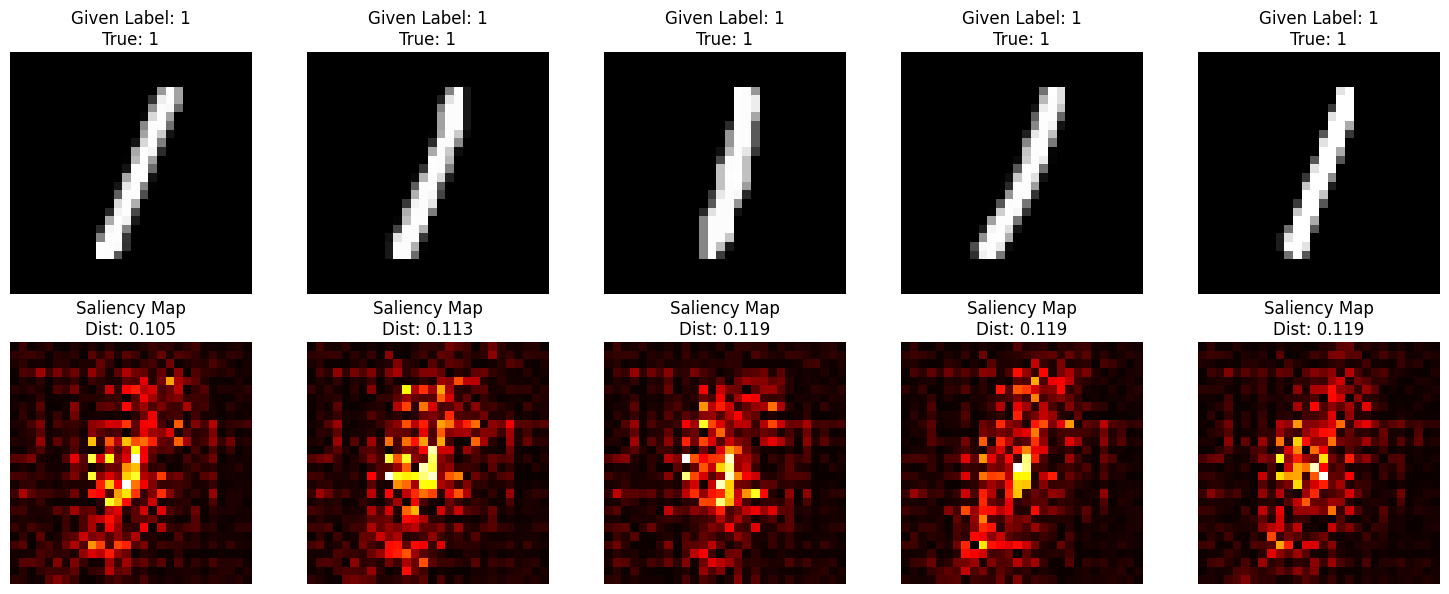

In [6]:
# 9. Visualize Suspicious vs. Typical Samples

# Sort by distance
sorted_indices = np.argsort(distances)[::-1] # Highest distance first

print("Visualizing TOP Suspicious Samples (Highest Saliency Distance)...")
plt.figure(figsize=(15, 6))
for i in range(5):
    idx = sorted_indices[i]
    img, label, _ = train_subset[idx]
    mask = all_masks[idx]
    
    plt.subplot(2, 5, i+1)
    plt.imshow(img[0], cmap='gray')
    plt.title(f"Given Label: {label}\nTrue: {true_targets[idx]}")
    plt.axis('off')
    
    plt.subplot(2, 5, i+6)
    plt.imshow(mask, cmap='hot')
    plt.title(f"Saliency Map\nDist: {distances[idx]:.3f}")
    plt.axis('off')
plt.tight_layout()
plt.show()

print("Visualizing TOP Typical Samples (Lowest Saliency Distance)...")
plt.figure(figsize=(15, 6))
bottom_indices = np.argsort(distances)
for i in range(5):
    idx = bottom_indices[i]
    img, label, _ = train_subset[idx]
    mask = all_masks[idx]
    
    plt.subplot(2, 5, i+1)
    plt.imshow(img[0], cmap='gray')
    plt.title(f"Given Label: {label}\nTrue: {true_targets[idx]}")
    plt.axis('off')
    
    plt.subplot(2, 5, i+6)
    plt.imshow(mask, cmap='hot')
    plt.title(f"Saliency Map\nDist: {distances[idx]:.3f}")
    plt.axis('off')
plt.tight_layout()
plt.show()

## Conclusion and Future Directions

In this exploration, we've demonstrated that **Saliency-Based Data Cleaning** is a viable technique for identifying label noise. By comparing individual saliency maps to a class-average "prototype," we were able to flag suspicious samples with higher-than-average distances.

### Key Observations:
1.  **Noise Signature:** Mislabeled samples tend to produce "messy" or "atypical" saliency maps as the model struggles to justify an incorrect label based on the input features.
2.  **Distance Metrics Matter:** Using `cosine_distance` from `saliencytools` provided a clear separation between clean and noisy distributions.
3.  **Self-Supervised Auditing:** This process doesn't require knowing the ground truth labels, making it suitable for auditing real-world datasets where labels might be unreliable.

### Potential Integration into `saliencytools`:
We could implement an `Auditor` module that automates this process:
- `Auditor.fit(train_dataset)`: Computes class-wise saliency prototypes.
- `Auditor.score(dataset)`: Returns "suspicion scores" for each sample.
- `Auditor.clean(dataset, threshold)`: Returns a filtered dataset.

This would extend the library's scope from simple "mask comparison" to "dataset-level explainable auditing."